# Résolution d’un problème de poutre console

---

## Origines historiques

L’étude de la **poutre en console** (*cantilever*) constitue l’un des premiers problèmes fondamentaux de la mécanique des structures.

En 1638, dans son ouvrage *Discours concernant deux sciences nouvelles*, **Galilée** propose une première analyse d’une poutre encastrée soumise à une charge.  

<div align="center">
    <img src="cantilever.png" alt="Poutre console" width="350" />
</div>

Bien que son modèle reste approximatif — notamment car il suppose une répartition simplifiée des contraintes — il introduit une idée essentielle :  
> la poutre peut être assimilée à un **levier**, avec une zone critique située à l’encastrement.

Au cours des siècles suivants, ces premières intuitions sont enrichies et rigoureusement formalisées.  
L’analyse des poutres évolue alors vers une description continue, fondée sur les lois de la mécanique et le calcul différentiel.

Cette évolution conduit à l’établissement de la **théorie d’Euler-Bernoulli**, qui constitue aujourd’hui le cadre classique pour modéliser le comportement des poutres en flexion.

---

### Cadre théorique

L’étude est menée dans le cadre de la **théorie d’Euler-Bernoulli**, basée sur les hypothèses suivantes :

- **Équilibre statique** (pas d’effets dynamiques),
- **Petites déformations**,
- **Matériau homogène et isotrope**,
- **Comportement linéaire élastique** (loi de Hooke),
- **Sections planes restent planes** (hypothèse de Navier-Bernoulli).

Ces hypothèses permettent d’obtenir une modélisation simplifiée et largement utilisée en ingénierie.

Dans ce cadre, la théorie d’Euler-Bernoulli relie le moment fléchissant à la courbure de la poutre :

$$
EI\, y''(x) = M(x)
$$

---

### Problématique étudiée

On considère une poutre :
- de longueur $L$,
- encastrée en $A$,
- soumise à un chargement extérieur ponctuel a son extrémité.

L’objectif est de déterminer :

- les **réactions d’appui**,
- les **efforts internes**,
- la **déformée**,
- les **contraintes** dans la structure.

In [ ]:
# Importation des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import fem, mesh, io, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI
import ufl
import json
from petsc4py import PETSc

print("Bibliothèques importées avec succès!")

import json

def load_problem():
    with open('problem.json', 'r') as f:
        return json.load(f)

problem = load_problem()

# Helper pour convertir les valeurs du JSON (gère "" et null)
def to_float(val):
    if val is None or val == "" or val == "null":
        return None
    return float(val)

def to_int(val):
    if val is None or val == "" or val == "null":
        return None
    return int(val)

Bibliothèques importées avec succès!


In [ ]:
# --- Données générales ---
L = to_float(problem['length'])
if L is None:
    raise ValueError("L (length) is missing in JSON")

E = problem['material']['E']
if E is None:
    raise ValueError("E (Young modulus) is missing in JSON")
E = float(E)
nu = to_float(problem['material']['nu'])

# --- Supports ---
supportA = problem['supports']['A']
supportB = problem['supports']['B']

# --- Section ---
section = problem["section"]

I = to_float(section["I"])
if I is None:
    raise ValueError("I (moment of inertia) is missing in JSON")

W = to_float(section.get("W"))
h_equiv = to_float(section.get("h_equiv"))
b = to_float(section.get("b"))
h = to_float(section.get("h"))
r = to_float(section.get("r"))
r_int = to_float(section.get("r_int"))
tw = to_float(section.get("tw"))
tf = to_float(section.get("tf"))

# --- Load ---
load = problem["load"]
load_type = load["type"]

P = to_float(load.get("P"))
a = to_float(load.get("xP"))
q = to_float(load.get("q"))
x_start = to_float(load.get("x_start"))
x_end = to_float(load.get("x_end"))

In [ ]:
# --- Checks ---
if load_type == "point_load":
    if P is None or a is None:
        raise ValueError("Point load requires P and xP")

if load_type == "distributed_load":
    if q is None:
        raise ValueError("Distributed load requires q")

# --- Affichage ---
print("=== Problem summary ===")
print(f"L = {L} m")
print(f"E = {E/1e9:.2f} GPa")
print(f"nu = {nu}")
print(f"I = {I:.6e} m^4")

if W:
    print(f"W = {W:.6e} m^3")

if h_equiv:
    print(f"h_equiv = {h_equiv} m")

print(f"Supports: A={supportA}, B={supportB}")
print(f"Load type: {load_type}")

if load_type == "point_load":
    print(f"P = {P} N at x = {a} m")

elif load_type == "distributed_load":
    print(f"q = {q} N/m from x = {x_start} to {x_end}")

## Réactions d’appui

Les réactions d’appui sont déterminées à partir des équations fondamentales de l’équilibre statique :

$$
\sum \vec{F} = 0
\quad ; \quad
\sum \vec{M} = 0
$$

Dans le cas d’un encastrement en $A$, l’appui impose :
- une réaction verticale $R_A$
- un moment d’encastrement $M_A$

In [ ]:
# =========================
# RÉACTIONS D'APPUI
# =========================

problem_name = problem["name"]
load_type = problem["load"]["type"]
supportA = problem["supports"]["A"]
supportB = problem["supports"]["B"]

# === Calcul des réactions en fonction du type de poutre et chargement ===
# Noms possibles: console_point, bi_encastre_point, encastre_rotule_point,
#                console_distributed, bi_encastre_distributed, encastre_rotule_distributed

# Cas console (encastré-libre) avec charge ponctuelle
if problem_name == "console_point":
    R_A = P
    M_A = P * a

# Cas console avec charge répartie
elif problem_name == "console_distributed":
    R_A = q * L
    M_A = q * L**2 / 2

# Cas bi-encastré avec charge ponctuelle
elif problem_name == "bi_encastre_point":
    R_A = P
    R_B = P
    M_A = P * a * (L - a) / L
    M_B = -P * a**2 * (L - a) / L**2

# Cas bi-encastré avec charge répartie
elif problem_name == "bi_encastre_distributed":
    R_A = q * L / 2
    R_B = q * L / 2
    M_A = q * L**2 / 12
    M_B = -q * L**2 / 12

# Cas encastré-rotulé avec charge ponctuelle
elif problem_name == "encastre_rotule_point":
    if a <= L:
        R_A = P * (3 * L**2 - 4 * a * L + a**2) / (2 * L**3)
        R_B = P - R_A
    else:
        R_A = P
        R_B = 0
    M_A = P * a * (L - a)**2 / (2 * L**3)

# Cas encastré-rotulé avec charge répartie
elif problem_name == "encastre_rotule_distributed":
    R_A = 5 * q * L / 8
    R_B = 3 * q * L / 8
    M_A = q * L**2 / 8

else:
    raise NotImplementedError(f"Cas non implémenté : {problem_name} (supportA={supportA}, supportB={supportB}, load_type={load_type})")


# =========================
# AFFICHAGE
# =========================

print("=== Réactions d'appui :",problem_name," ===" )
print(f"R_A = {R_A:.2f} N")

if 'R_B' in locals():
    print(f"R_B = {R_B:.2f} N")

if 'M_A' in locals():
    print(f"M_A = {M_A:.2f} N·m")
    
if 'M_B' in locals():
    print(f"M_B = {M_B:.2f} N·m")

=== Réactions d'appui : console_point  ===
R_A = 1000.00 N
M_A = 1000.00 N·m


## Efforts internes — méthode des coupures

### Principe

On considère une section droite de la poutre à l’abscisse $x$.  
L’isolement d’une portion de la structure permet, par application des équations d’équilibre, de déterminer les efforts internes dans la section.

Cette démarche repose sur le principe de Saint-Venant : les efforts internes en une section dépendent uniquement des actions mécaniques appliquées sur l’une des parties isolées.

---

### Définition des efforts internes

Dans une section droite, les actions mécaniques internes sont décrites par le torseur des efforts internes.

Pour une poutre sollicitée dans son plan, on distingue :
- l’effort normal $N(x)$ : effort de traction ou de compression suivant l’axe de la poutre
- l’effort tranchant $V(x)$ : effort de cisaillement dans la section
- le moment fléchissant $M(x)$ : moment responsable de la flexion de la poutre

La détermination de ces grandeurs le long de la poutre permet d’établir les diagrammes des efforts internes.

In [ ]:
# === Méthode des coupures ===
print("=== Méthode des coupures ===")

# Variables: problem_name, load_type, P, q, a, x_start, x_end, L, R_A, M_A, R_B, M_B

if problem_name == "console_point":
    print("Segments définis:")
    print("  Segment 1: 0 ≤ x < a")
    print("  Segment 2: a ≤ x ≤ L")
    print()
    print("--- Segment 1 (0 ≤ x < a) ---")
    print(f"V(x) = -R_A = -{R_A:.2f} N")
    print(f"M(x) = -M_A - R_A·x = -{M_A:.2f} - {R_A:.2f}·x")
    print()
    print("--- Segment 2 (a ≤ x ≤ L) ---")
    print(f"V(x) = -R_A + P = -{R_A:.2f} + {P:.2f} = {R_A-P:.2f} N")
    print(f"M(x) = -M_A - R_A·x + P·(x-a)")

elif problem_name == "bi_encastre_point":
    print("Segments définis:")
    print("  Segment 1: 0 ≤ x < a")
    print("  Segment 2: a ≤ x ≤ L")
    print()
    print("--- Segment 1 ---")
    print(f"V(x) = R_A = {R_A:.2f} N")
    print(f"M(x) = M_A + R_A·x")
    print()
    print("--- Segment 2 ---")
    print(f"V(x) = R_A - P")
    print(f"M(x) = M_A + R_A·x - P·(x-a)")

elif problem_name == "encastre_rotule_point":
    print("Segments définis:")
    print("  Segment 1: 0 ≤ x < a")
    print("  Segment 2: a ≤ x ≤ L")
    print()
    print("--- Segment 1 ---")
    print(f"V(x) = R_A = {R_A:.2f} N")
    print(f"M(x) = M_A + R_A·x")
    print()
    print("--- Segment 2 ---")
    print(f"V(x) = R_A - P")
    print(f"M(x) = M_A + R_A·x - P·(x-a)")

elif problem_name == "console_distributed":
    print("Charge répartie → découpe continue")
    print("dV/dx = -q")
    print("dM/dx = V")
    print()
    print(f"V(x) = R_A - q·x = {R_A:.2f} - {q:.2f}·x")
    print(f"M(x) = M_A + R_A·x - q·x²/2")

elif problem_name == "bi_encastre_distributed":
    print("Charge répartie → découpe continue")
    print("dV/dx = -q")
    print("dM/dx = V")
    print()
    print(f"V(x) = R_A - q·x")
    print(f"M(x) = M_A + R_A·x - q·x²/2")

elif problem_name == "encastre_rotule_distributed":
    print("Charge répartie → découpe continue")
    print("dV/dx = -q")
    print("dM/dx = V")
    print()
    print(f"V(x) = R_A - q·x")
    print(f"M(x) = M_A + R_A·x - q·x²/2")

else:
    print(f"Cas {problem_name} non implémenté pour l'affichage analytique")

=== Méthode des coupures ===
Segments définis:
  Segment 1: 0 ≤ x < a
  Segment 2: a ≤ x ≤ L

--- Segment 1 (0 ≤ x < a) ---
V(x) = -R_A = -1000.00 N
M(x) = -M_A - R_A·x = -1000.00 - 1000.00·x

--- Segment 2 (a ≤ x ≤ L) ---
V(x) = -R_A + P = -1000.00 + 1000.00 = 0.00 N
M(x) = -M_A - R_A·x + P·(x-a)


In [ ]:
# =========================
# EFFORTS INTERNES (général)
# =========================

def N(x):
    return 0


def V(x):
    v = 0

    # réaction A
    if supportA in ["fixed", "pin"]:
        v -= R_A

    # réaction B
    if 'R_B' in locals() and x >= L:
        v -= R_B

    # charge ponctuelle
    if load_type == "point_load" and x >= a:
        v += P

    # charge répartie
    if load_type == "distributed_load" and x >= x_start:
        x_eff = min(x, x_end)
        v += q * (x_eff - x_start)

    return v


def M(x):
    if load_type == "point_load":
        if x <= a:
            return -P * (a - x)
        else:
            return 0

    # fallback générique
    m = 0

    if supportA in ["fixed", "pin"]:
        m -= R_A * x

    if load_type == "distributed_load" and x >= x_start:
        x_eff = min(x, x_end)
        m += q * (x_eff - x_start)**2 / 2

    return m


# Discrétisation
x = np.linspace(0, L, 500)

N_vals = np.array([N(xi) for xi in x])
V_vals = np.array([V(xi) for xi in x])
M_vals = np.array([M(xi) for xi in x])


print("=== Fonctions des efforts internes ===")
print(f"V(0) = {V(0)} N")
print(f"V(L) = {V(L)} N")
print(f"M(0) = {M(0)} N·m")
print(f"M(L) = {M(L)} N·m")

V_max = np.max(np.abs(V_vals))
M_max = np.max(np.abs(M_vals))

print("\n=== Résultats globaux ===")
print(f"Effort tranchant max : Vmax = {V_max:.2f} N")
print(f"Moment fléchissant max : Mmax = {M_max:.2f} N·m")

=== Fonctions des efforts internes ===
V(0) = -1000.0 N
V(L) = 0.0 N
M(0) = -1000.0 N·m
M(L) = -0.0 N·m

=== Résultats globaux ===
Effort tranchant max : Vmax = 1000.00 N
Moment fléchissant max : Mmax = 1000.00 N·m


## Diagrammes $N(x)$, $V(x)$, $M(x)$

Les diagrammes des efforts internes représentent l’évolution des sollicitations le long de la poutre.

Ils sont obtenus à partir des expressions de $N(x)$, $V(x)$ et $M(x)$ établies précédemment, et permettent d’identifier les zones les plus sollicitées de la structure.

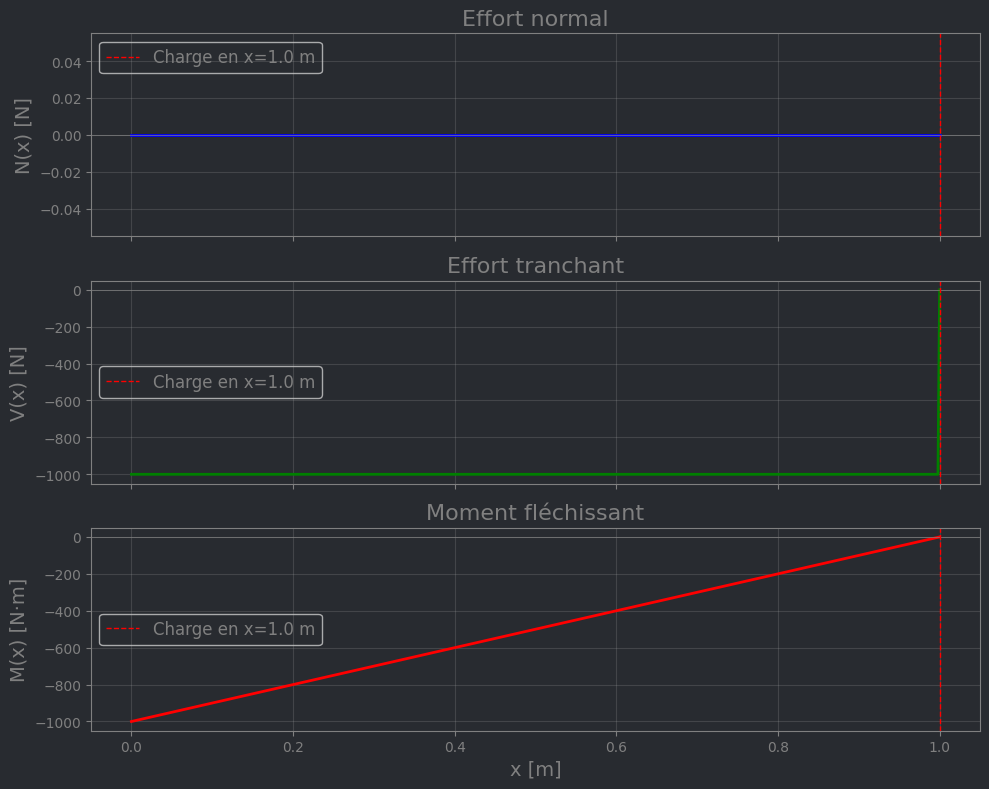

In [ ]:
# Tracé des diagrammes des efforts internes

# =========================
# STYLE GLOBAL
# =========================
bg = (40/255, 43/255, 48/255, 1.0)

plt.rcParams['figure.facecolor'] = bg
plt.rcParams['axes.facecolor'] = bg
plt.rcParams['savefig.facecolor'] = bg

plt.rcParams['axes.edgecolor'] = '0.5'
plt.rcParams['xtick.color'] = '0.5'
plt.rcParams['ytick.color'] = '0.5'

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# =========================
# 1. EFFORT NORMAL N(x)
# =========================
axes[0].plot(x, N_vals, 'b-', linewidth=2)
axes[0].axhline(y=0, color='grey', linestyle='-', linewidth=0.5)
axes[0].axvline(x=a, color='red', linestyle='--', linewidth=1,
                label=f'Charge en x={a} m')

axes[0].set_ylabel('N(x) [N]', color='grey', fontsize=14)
axes[0].set_title('Effort normal', color='grey', fontsize=16)

axes[0].legend(labelcolor='grey', facecolor='none', fontsize=12)
axes[0].tick_params(colors='grey')
axes[0].grid(True, alpha=0.2)

# =========================
# 2. EFFORT TRANCHANT V(x)
# =========================
axes[1].plot(x, V_vals, 'g-', linewidth=2)
axes[1].axhline(y=0, color='grey', linestyle='-', linewidth=0.5)
axes[1].axvline(x=a, color='red', linestyle='--', linewidth=1,
                label=f'Charge en x={a} m')

axes[1].set_ylabel('V(x) [N]', color='grey', fontsize=14)
axes[1].set_title('Effort tranchant', color='grey', fontsize=16)

axes[1].legend(labelcolor='grey', facecolor='none', fontsize=12)
axes[1].tick_params(colors='grey')
axes[1].grid(True, alpha=0.2)

# =========================
# 3. MOMENT FLÉCHISSANT M(x)
# =========================
axes[2].plot(x, M_vals, 'r-', linewidth=2)
axes[2].axhline(y=0, color='grey', linestyle='-', linewidth=0.5)
axes[2].axvline(x=a, color='red', linestyle='--', linewidth=1,
                label=f'Charge en x={a} m')

axes[2].set_xlabel('x [m]', color='grey', fontsize=14)
axes[2].set_ylabel('M(x) [N·m]', color='grey', fontsize=14)
axes[2].set_title('Moment fléchissant', color='grey', fontsize=16)

axes[2].legend(labelcolor='grey', facecolor='none', fontsize=12)
axes[2].tick_params(colors='grey')
axes[2].grid(True, alpha=0.2)

# =========================
# LAYOUT + SAVE
# =========================

plt.tight_layout()
#plt.savefig('diagrammes.png', dpi=150)
plt.show()

#print("Diagrammes sauvegardés dans 'diagrammes.png'")

## Calcul de la flèche $y(x)$

La déformée d’une poutre, ou flèche $y(x)$, permet de vérifier l’État Limite de Service (ELS), en contrôlant les déplacements de la structure.

Elle est obtenue à partir de l’équation fondamentale de la théorie d’Euler-Bernoulli :

$$
EI\, y''(x) = M(x)
$$

où $E$ est le module de Young et $I$ le moment d’inertie de la section.

La double intégration de cette relation permet d’obtenir $y(x)$, les constantes étant déterminées à partir des conditions aux limites (encastrement, appuis, etc.).

=== Rigidité ===
I = 1.330000e-04 m^4
EI = 2.793e+07 N·m²


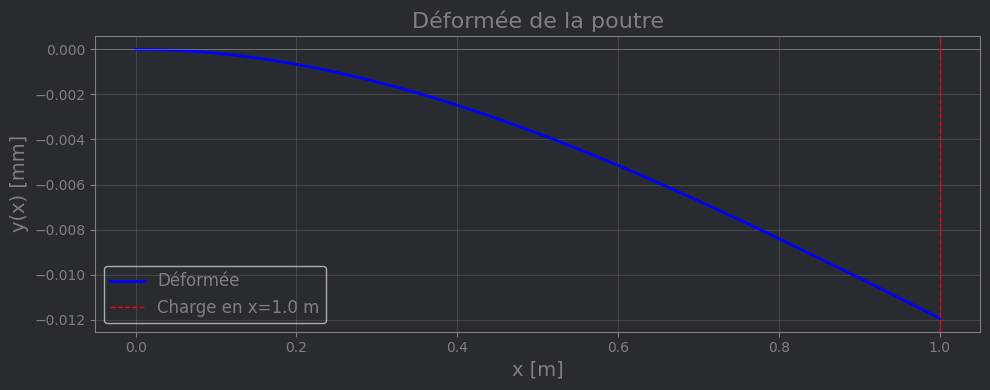

In [ ]:
# =========================
# FLÈCHE (MODE 2 PROPRE)
# =========================

I = float(problem["section"]["I"])
EI = E * I

print("=== Rigidité ===")
print(f"I = {I:.6e} m^4")
print(f"EI = {EI:.3e} N·m²")


# =========================
# DISCRÉTISATION
# =========================

x_fleche = np.linspace(0, L, 1000)

# =========================
# y''(x)
# =========================

def curvature(x):
    return M(x) / EI


# =========================
# INTÉGRATION 1 : θ(x)
# =========================

theta = np.zeros_like(x_fleche)

for i in range(1, len(x_fleche)):
    dx = x_fleche[i] - x_fleche[i - 1]

    k1 = curvature(x_fleche[i - 1])
    k2 = curvature(x_fleche[i])

    theta[i] = theta[i - 1] + 0.5 * (k1 + k2) * dx


# =========================
# INTÉGRATION 2 : y(x)
# =========================

y = np.zeros_like(x_fleche)

for i in range(1, len(x_fleche)):
    dx = x_fleche[i] - x_fleche[i - 1]

    y[i] = y[i - 1] + 0.5 * (theta[i - 1] + theta[i]) * dx


# =========================
# CONDITIONS AUX LIMITES
# =========================

# condition géométrique universelle
y = y - y[0]

# correction encastrement (si fixé)
if supportA == "fixed":
    theta = theta - theta[0]


# =========================
# RÉSULTATS
# =========================

y_max = np.min(y)
x_max = x_fleche[np.argmin(y)]


# =========================
# STYLE GLOBAL
# =========================
bg = (40/255, 43/255, 48/255, 1.0)

plt.rcParams['figure.facecolor'] = bg
plt.rcParams['axes.facecolor'] = bg
plt.rcParams['savefig.facecolor'] = bg

plt.rcParams['axes.edgecolor'] = '0.5'
plt.rcParams['xtick.color'] = '0.5'
plt.rcParams['ytick.color'] = '0.5'

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(10, 4))

# courbe
ax.plot(x_fleche, y * 1000,
        'b-', linewidth=2,
        label='Déformée')

# ligne neutre
ax.axhline(y=0, color='grey', linewidth=0.5)

# position charge
if load_type == "point_load":
    ax.axvline(x=a,
               color='red',
               linestyle='--',
               linewidth=1,
               label=f'Charge en x={a} m')

# =========================
# LABELS
# =========================
ax.set_xlabel('x [m]', color='grey', fontsize=14)
ax.set_ylabel('y(x) [mm]', color='grey', fontsize=14)
ax.set_title('Déformée de la poutre', color='grey', fontsize=16)

# ticks
ax.tick_params(colors='grey')

# légende
ax.legend(labelcolor='grey', facecolor='none', fontsize=12)

# grille
ax.grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('deformee.png', dpi=150)
plt.show()

## Contraintes normales de flexion $\sigma(x)$

Les contraintes normales de flexion traduisent la répartition des efforts internes dans la section d’une poutre soumise à un moment fléchissant.

Elles sont données par la relation :

$$
\sigma(x,y) = \frac{M(x)\, y}{I}
$$

où $y$ est la distance à la fibre neutre et $I$ le moment d’inertie de la section.

Cette expression montre que les contraintes sont maximales aux fibres extrêmes de la section.

=== Contraintes de flexion ===
|M_max| = 1000.00 N·m
|σ_max| = 7.50e+05 Pa
        = 0.75 MPa


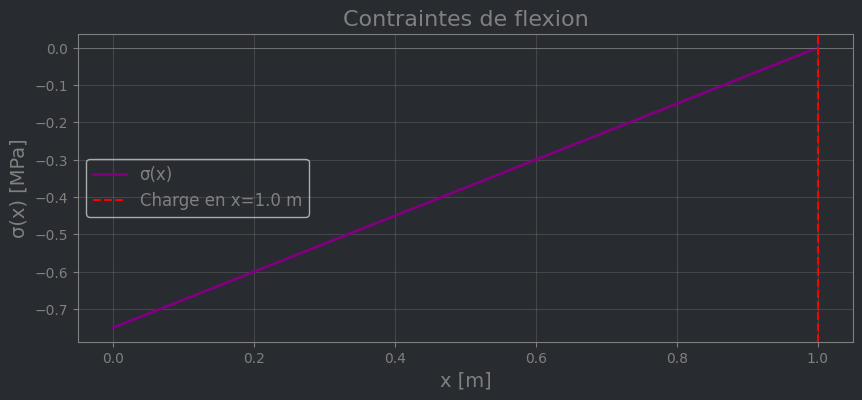


=== Vérification contrainte (Eurocode simplifié) ===
Limite élastique: 250.0 MPa
Contrainte maxi: 0.75 MPa
Coefficient de sécurité: 333.25
✓ Résistance OK (EC3)

=== Vérification flèche (Eurocode EC2 simplifié) ===
Flèche max: 0.01 mm
Limite admissible: 4.00 mm
✓ Flèche conforme Eurocode


In [ ]:
# =========================
# CONTRAINTES + EUROCODE
# =========================
section = problem["section"]
W = section["W"]

if W is None:
    print("⚠ W non défini, calcul des contraintes ignoré")
else:
    W = float(W)

    # --- Contraintes ---
    M_max = np.max(np.abs(M_vals))
    sigma_vals = M_vals / W
    sigma_max = np.max(np.abs(sigma_vals))

    print("=== Contraintes de flexion ===")
    print(f"|M_max| = {M_max:.2f} N·m")
    print(f"|σ_max| = {sigma_max:.2e} Pa")
    print(f"        = {sigma_max/1e6:.2f} MPa")

    # =========================
    # DIAGRAMME CONTRAINTES
    # =========================
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(x, sigma_vals / 1e6,
            color='purple',
            linewidth=2,
            label='σ(x)')

    ax.axhline(y=0, color='grey', linewidth=0.5)

    # position des charges
    if load_type == "point_load":
        ax.axvline(x=a,
                   color='red',
                   linestyle='--',
                   label=f'Charge en x={a} m')

    elif load_type == "distributed_load":
        ax.axvline(x_start, color='red', linestyle='--')
        ax.axvline(x_end, color='red', linestyle='--')

    # =========================
    # LABELS
    # =========================
    ax.set_xlabel('x [m]', color='grey', fontsize=14)
    ax.set_ylabel('σ(x) [MPa]', color='grey', fontsize=14)
    ax.set_title('Contraintes de flexion', color='grey', fontsize=16)

    ax.tick_params(colors='grey')

    ax.legend(labelcolor='grey', facecolor='none', fontsize=12)

    ax.grid(True, alpha=0.2)

    #plt.tight_layout()

    #plt.savefig("contraintes.png")

    plt.show()

    # =========================
    # VÉRIFICATION CONTRAINTE (EC3)
    # =========================
    limite_elastique = 250e6  # S235

    coefficient_securite = limite_elastique / sigma_max

    print("\n=== Vérification contrainte (Eurocode simplifié) ===")
    print(f"Limite élastique: {limite_elastique/1e6:.1f} MPa")
    print(f"Contrainte maxi: {sigma_max/1e6:.2f} MPa")
    print(f"Coefficient de sécurité: {coefficient_securite:.2f}")

    if sigma_max < limite_elastique:
        print("✓ Résistance OK (EC3)")
    else:
        print("✗ NON CONFORME EC3 - section insuffisante")

    contrainte_ok = bool(sigma_max < limite_elastique)

    # =========================
    # VÉRIFICATION FLÈCHE (EC2)
    # =========================
    delta_max = np.abs(y_max)
    delta_lim = L / 250

    print("\n=== Vérification flèche (Eurocode EC2 simplifié) ===")
    print(f"Flèche max: {delta_max*1000:.2f} mm")
    print(f"Limite admissible: {delta_lim*1000:.2f} mm")

    if delta_max < delta_lim:
        print("✓ Flèche conforme Eurocode")
    else:
        print("✗ Flèche NON conforme Eurocode")

    fleche_ok = bool(delta_max < delta_lim)
    status_global = bool(contrainte_ok and fleche_ok)

## Environnement de calcul et POC (DAG)

Cette section présente un environnement de calcul reproductible dédié aux simulations numériques en mécanique des structures et à l’optimisation.

L’objectif du POC est de démontrer la capacité de la plateforme DAG à fournir un cadre unifié pour :

- la simulation par éléments finis (FEM),
- l’exploration de paramètres physiques,
- et la mise en place de workflows numériques reproductibles.

Dans ce cadre, la poutre étudiée précédemment sert de cas d’application pour illustrer l’utilisation de l’environnement dans un contexte de mécanique des structures.

In [ ]:
# =========================
# MAILLAGE 3D CENTRÉ
# =========================
nx = 21
ny = 11
nz = ny

msh = mesh.create_box(
    MPI.COMM_WORLD,
    points=[
        np.array([
            0.0,
            -h_equiv / 2,
            -h_equiv / 2
        ]),
        np.array([
            L,
            h_equiv / 2,
            h_equiv / 2
        ])
    ],
    n=[nx, ny, nz],
    cell_type=mesh.CellType.hexahedron
)


In [ ]:
# =========================
# ESPACE FONCTIONNEL
# =========================
V = fem.functionspace(msh, ("Lagrange", 1, (3,)))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

In [ ]:
# =========================
# CONDITIONS AUX LIMITES (encastrement x=0)
# =========================
def left(x):
    return np.isclose(x[0], 0.0)

left_dofs = fem.locate_dofs_geometrical(V, left)

bc = fem.dirichletbc(
    np.array((0.0, 0.0, 0.0), dtype=PETSc.ScalarType),
    left_dofs,
    V
)

In [ ]:
# =========================
# CHARGEMENTS PONCTUELLE
# =========================

tol = L / ny

def load_patch(x):
    return (
        (np.abs(x[0] - L) < tol) &
        (np.abs(x[1]) <= 0.51 * h_equiv) &
        (x[2] > 0.49 * h_equiv)
    )

fdim = msh.topology.dim - 1

facets = mesh.locate_entities_boundary(msh, fdim, load_patch)

facet_tag = mesh.meshtags(
    msh,
    fdim,
    facets,
    np.full(len(facets), 1, dtype=np.int32)
)

ds = ufl.Measure("ds", domain=msh, subdomain_data=facet_tag)

area = fem.assemble_scalar(fem.form(1 * ds(1)))

g = fem.Constant(
    msh,
    PETSc.ScalarType((0.0, 0.0, -P / area))
)

In [ ]:
# =========================
# MÉCANIQUE
# =========================
mu = E / (2 * (1 + nu))
lmbda = E * nu / ((1 + nu) * (1 - 2 * nu))

def epsilon(u):
    return ufl.sym(ufl.grad(u))

def sigma(u):
    return (
        lmbda * ufl.tr(epsilon(u)) * ufl.Identity(3)
        + 2 * mu * epsilon(u)
    )

In [ ]:
# =========================
# FORMULATION FAIBLE
# =========================
a_form = ufl.inner(sigma(u), epsilon(v)) * ufl.dx(domain=msh)

f = fem.Constant(
    msh,
    PETSc.ScalarType((0.0, 0.0, 0.0))
)

L_form = ufl.inner(g, v) * ds(1)

In [ ]:
# =========================
# RÉSOLUTION
# =========================
problema = LinearProblem(
    a_form,
    L_form,
    bcs=[bc],
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

uh = problema.solve()

print("✅ Problème résolu")

# =========================
# POST SAFE
# =========================
vals = uh.x.array
w_max = np.min(vals)
print("Flèche max (mm) =", w_max * 1000)

✅ Problème résolu
Flèche max (mm) = -0.011334761009873098


In [ ]:
# =========================
# POST-TRAITEMENT
# =========================
# Von Mises
sigma_u = sigma(uh)

dev = sigma_u - (1/3) * ufl.tr(sigma_u) * ufl.Identity(3)
von_Mises = ufl.sqrt(3/2 * ufl.inner(dev, dev))

Vsig = fem.functionspace(msh, ("Lagrange", 1))
vm = fem.Function(Vsig)

vm_expr = fem.Expression(von_Mises, Vsig.element.interpolation_points())
vm.interpolate(vm_expr)

# =========================
# EXPORT PARAVIEW
# =========================
#with io.XDMFFile(MPI.COMM_WORLD, "beam_results.xdmf", "w") as file:
#    file.write_mesh(msh)
#    uh.name = "Displacement"
#    vm.name = "Von_Mises"
#    file.write_function(uh)
#    file.write_function(vm)

#print("✅ Résultats exportés (Paraview)")

In [ ]:
import pyvista as pv
import numpy as np
from dolfinx import plot

# =========================
# MESH -> PYVISTA
# =========================
cells, types, x = plot.vtk_mesh(msh)
grid = pv.UnstructuredGrid(cells, types, x)

# =========================
# SURFACE
# =========================
surface = grid.extract_surface()

# =========================
# INITIALISATION
# =========================
load_zone = np.zeros(surface.n_points)

import pyvista as pv
import numpy as np
from dolfinx import plot, mesh

# =========================
# MESH -> PYVISTA
# =========================
cells, types, x = plot.vtk_mesh(msh)
grid = pv.UnstructuredGrid(cells, types, x)

surface = grid.extract_surface()
surface_points = np.asarray(surface.points)

load_zone = np.zeros(len(surface_points))

# =========================
# MAPPING VIA COORDONNÉES FEM (PAS DE REDEFINITION PHYSIQUE)
# =========================
for f in facets:
    vertices = mesh.compute_incident_entities(
        msh.topology,
        np.array([f], dtype=np.int32),
        msh.topology.dim - 1,
        0
    )

    coords = msh.geometry.x[vertices]

    for c in coords:
        mask = np.all(np.isclose(surface_points, c), axis=1)
        load_zone[mask] = 1.0

surface["load_zone"] = load_zone

print("Nb points marqués =", np.sum(load_zone))
print("Nb facets FEM =", len(facets))

# =========================
# VISU
# =========================
plotter = pv.Plotter()
plotter.set_background("gray")

plotter.add_mesh(grid, style="wireframe", opacity=0.2)

plotter.add_mesh(
    surface,
    scalars="load_zone",
    cmap="coolwarm"
)

plotter.show()

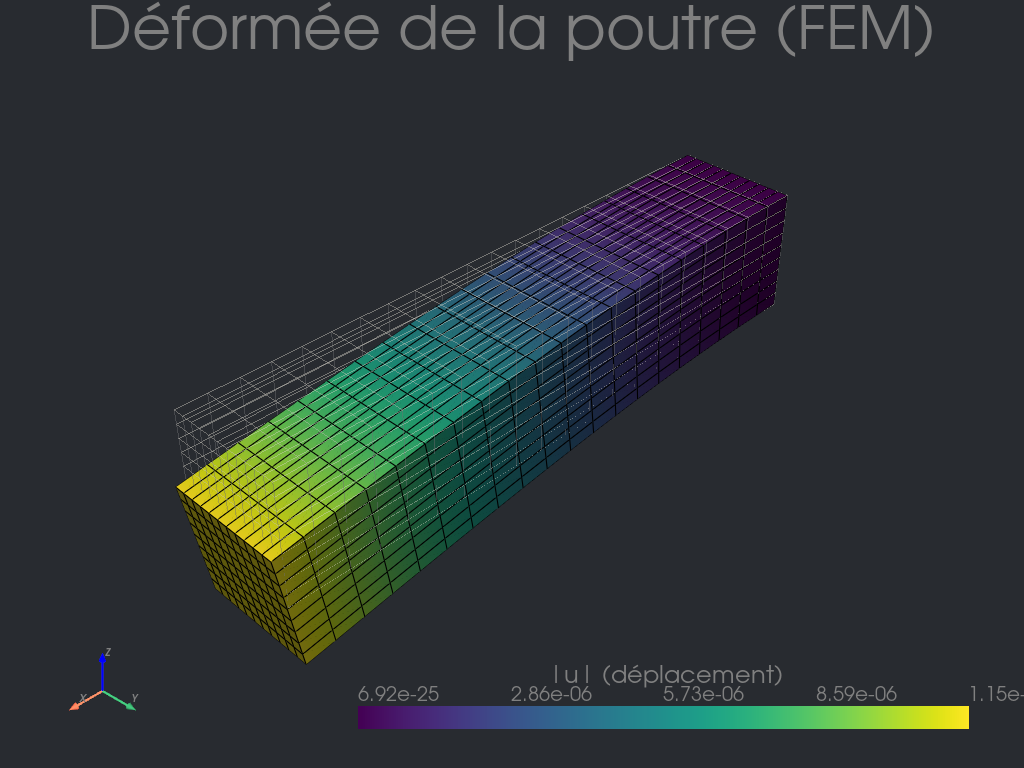

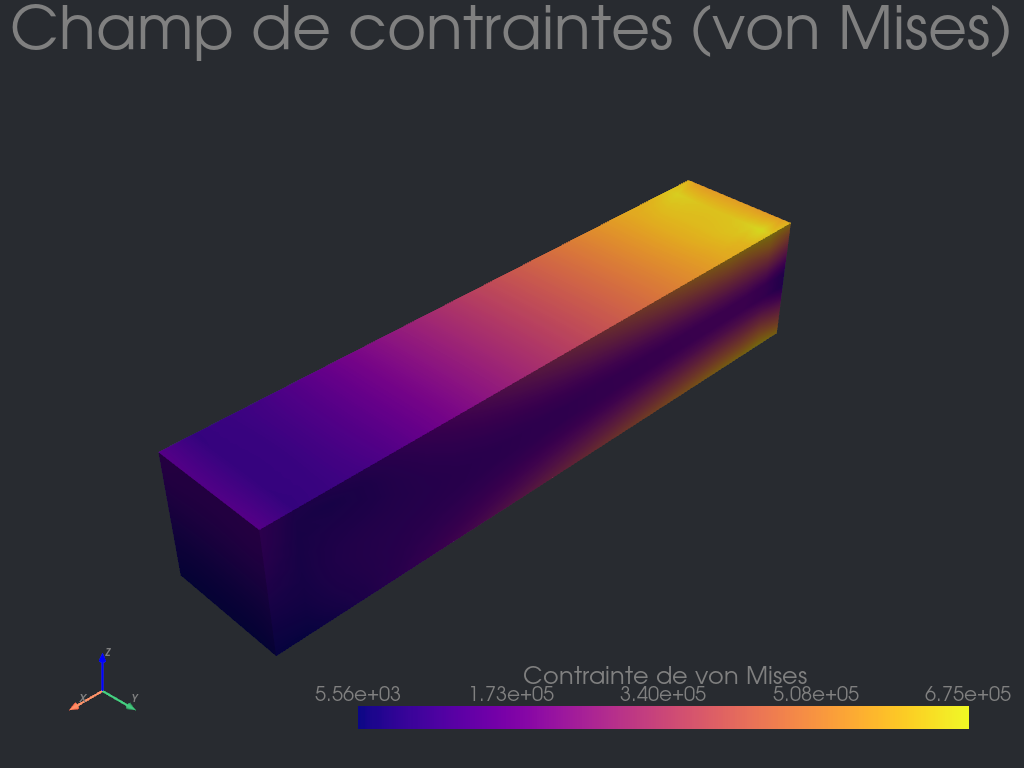

In [ ]:
import pyvista as pv
import numpy as np
from dolfinx import plot, geometry

# =========================
# STYLE GLOBAL
# =========================
#custom_bg = (0.157, 0.169, 0.188, 1.0)
custom_bg = (40/255, 43/255, 48/255, 1.0)
text_color = "gray"
title_size = 24
label_size = 20

# =========================
# CONVERSION MESH
# =========================
cells, types, x = plot.vtk_mesh(msh)
grid = pv.UnstructuredGrid(cells, types, x)

num_vertices = x.shape[0]
points = x

# =========================
# LOCALISATION CELLULES
# =========================
tree = geometry.bb_tree(msh, msh.topology.dim)
candidates = geometry.compute_collisions_points(tree, points)
colliding_cells = geometry.compute_colliding_cells(msh, candidates, points)

cell_indices = np.array([
    colliding_cells.links(i)[0] if len(colliding_cells.links(i)) > 0 else -1
    for i in range(num_vertices)
], dtype=np.int32)

# =========================
# DÉPLACEMENT
# =========================
u_at_pts = uh.eval(points, cell_indices)
u_norm = np.linalg.norm(u_at_pts, axis=1)
grid["|u|"] = u_norm

# =========================
# VISUALISATION DÉFORMÉE
# =========================
plotter = pv.Plotter()
plotter.set_background(custom_bg)

# maillage initial
plotter.add_mesh(grid,
                 style="wireframe",
                 color="white",
                 opacity=0.25)

# déformée amplifiée
deformed = grid.copy()
deformed.points += u_at_pts * 10000

plotter.add_mesh(deformed,
                 scalars="|u|",
                 cmap="viridis",
                 show_edges=True,
                 scalar_bar_args={
                     "title": "|u| (déplacement)",
                     "title_font_size": title_size,
                     "label_font_size": label_size,
                     "color": text_color,
                     "shadow": False,
                     "italic": False,
                     "font_family": "arial"
                 })

# TITRE
plotter.add_text("Déformée de la poutre (FEM)",
                 font_size=24,
                 color=text_color,
                 position="upper_edge")

plotter.add_axes(xlabel='X', ylabel='Y', zlabel='Z', color=text_color)
plotter.view_isometric()

plotter.show(jupyter_backend="static")

# =========================
# VON MISES
# =========================
vm_at_pts = vm.eval(points, cell_indices)
grid["von_Mises"] = vm_at_pts

# =========================
# VISUALISATION VON MISES
# =========================
plotter = pv.Plotter()
plotter.set_background(custom_bg)

plotter.add_mesh(grid,
                 scalars="von_Mises",
                 cmap="plasma",
                 show_edges=False,
                 scalar_bar_args={
                     "title": "Contrainte de von Mises",
                     "title_font_size": title_size,
                     "label_font_size": label_size,
                     "color": text_color,
                     "shadow": False,
                     "font_family": "arial"
                 })

plotter.add_text("Champ de contraintes (von Mises)",
                 font_size=24,
                 color=text_color,
                 position="upper_edge")

plotter.add_axes(xlabel='X', ylabel='Y', zlabel='Z', color=text_color)
plotter.view_isometric()

plotter.show(jupyter_backend="static")

The following objects are defined with multiple values in their parent components, so they inherit the value from the component which is the component name with the highest ASCII order among their parent components including them.

Object: 'V', Inherited from: Component 'stress'
Object: 'x', Inherited from: Component 'stress'

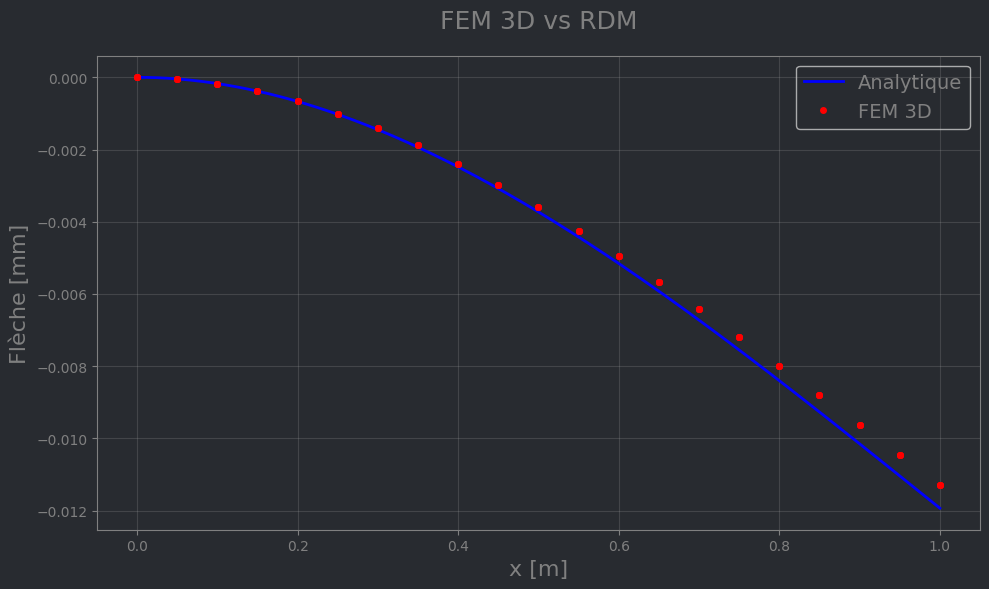

In [ ]:
# =========================
# EXTRACTION LIGNE NEUTRE (y=0, z=0)
# =========================

coords = msh.geometry.x

# tolérance géométrique

tol_y = h_equiv / ny
tol_z = h_equiv / nz

r = np.sqrt(coords[:,1]**2 + coords[:,2]**2)
mask = r < min(tol_y, tol_z)

x_coords = coords[mask, 0]

# déplacement FEM
u_vals = uh.x.array.reshape(-1, 3)
u_z = u_vals[mask, 2]  # flèche verticale

# tri selon x
order = np.argsort(x_coords)
x_coords = x_coords[order]
u_z = u_z[order]

# =========================
# ANALYTIQUE
# =========================
x_analytique = x_fleche
y_analytique_vals = y

# =========================
# STYLE GLOBAL
# =========================
bg = (40/255, 43/255, 48/255, 1.0)

plt.rcParams['figure.facecolor'] = bg
plt.rcParams['axes.facecolor'] = bg
plt.rcParams['savefig.facecolor'] = bg

plt.rcParams['axes.edgecolor'] = '0.5'
plt.rcParams['xtick.color'] = '0.5'
plt.rcParams['ytick.color'] = '0.5'

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

# Courbes
ax.plot(x_analytique, y_analytique_vals * 1000,
        'b-', linewidth=2, label='Analytique')

ax.plot(x_coords, u_z * 1000,
        'ro', markersize=4, label='FEM 3D')

# =========================
# AXES (EN GRIS)
# =========================
ax.set_xlabel('x [m]', color='grey', fontsize=16)
ax.set_ylabel('Flèche [mm]', color='grey', fontsize=16)
ax.set_title('FEM 3D vs RDM', color='grey', fontsize=18, pad=20)

# ticks bien gris
ax.tick_params(colors='grey')

# =========================
# LÉGENDE (GRISE)
# =========================
ax.legend(labelcolor='grey', facecolor='none', fontsize=14)

# =========================
# GRILLE
# =========================
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

L’erreur relative est définie par :

$$
\varepsilon = \frac{|y_{\max}^{FEM} - y_{\max}^{ref}|}{y_{\max}^{ref}}
$$

In [ ]:
# =========================
# COMPARAISON
# =========================

y_fem_at_L = u_z[-1]
y_analytique_at_L = np.interp(L, x_analytique, y_analytique_vals)

erreur_relative = abs(y_fem_at_L - y_analytique_at_L) / abs(y_analytique_at_L) * 100

# =========================
# JSON FINAL
# =========================

result = {
    "comparaison": {
        "analytique_mm": y_analytique_at_L * 1000,
        "fem_mm": y_fem_at_L * 1000,
        "erreur_pourcent": erreur_relative
    },
    "contrainte": {
        "limite_MPa": limite_elastique / 1e6,
        "sigma_max_MPa": sigma_max / 1e6,
        "coefficient_securite": coefficient_securite,
        "ok": contrainte_ok
    },
    "fleche": {
        "delta_max_mm": delta_max * 1000,
        "delta_lim_mm": delta_lim * 1000,
        "ok": fleche_ok
    },
    "status_global": status_global
}

# Debug lisible
print(json.dumps(result, indent=2))

# Sauvegarde pour Go
with open("output.json", "w") as f:
    json.dump(result, f)

erreur_relative

{
  "comparaison": {
    "analytique_mm": -0.01193459541113796,
    "fem_mm": -0.011293648305794048,
    "erreur_pourcent": 5.370497140990199
  },
  "contrainte": {
    "limite_MPa": 250.0,
    "sigma_max_MPa": 0.7501875468867217,
    "coefficient_securite": 333.25,
    "ok": true
  },
  "fleche": {
    "delta_max_mm": 0.01193459541113796,
    "delta_lim_mm": 4.0,
    "ok": true
  },
  "status_global": true
}


np.float64(5.370497140990199)